In [ ]:
import warnings


warnings.filterwarnings("ignore")

# NLP (Natural language processing)

In [ ]:
import pandas as pd
import numpy as np

# emotion_nlp

In [ ]:
pd.read_csv(r'C:\Users\sudha\OneDrive\Desktop\files\Files\emotion_nlp.csv')

,Text,Emotions
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
17994,i just keep feeling like someone is being unki...,anger
17995,im feeling a little cranky negative after this...,anger
17996,i feel that i am useful to my people and that ...,joy
17997,im feeling more comfortable with derby i feel ...,joy


In [ ]:
em=pd.read_csv(r'C:\Users\sudha\OneDrive\Desktop\files\Files\emotion_nlp.csv')

In [ ]:
em.Emotions.value_counts()

Emotions
joy         6056
sadness     5247
anger       2434
fear        2161
love        1463
surprise     638
Name: count, dtype: int64

In [ ]:
em.isnull().sum()[em.isnull().sum()>0]

Series([], dtype: int64)

In [ ]:
em.Emotions.unique()

array(['sadness', 'anger', 'love', 'surprise', 'fear', 'joy'],
      dtype=object)

In [ ]:
em=em.rename(columns={'Emotions':'y','Text':'x'})

In [ ]:
em.head()

,x,y
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [ ]:
em=em.replace({'sadness':1,'anger':2,'love':3,'surprise':4,'fear':5,'joy':6})
em

,x,y
0,i didnt feel humiliated,1
1,i can go from feeling so hopeless to so damned...,1
2,im grabbing a minute to post i feel greedy wrong,2
3,i am ever feeling nostalgic about the fireplac...,3
4,i am feeling grouchy,2
...,...,...
17994,i just keep feeling like someone is being unki...,2
17995,im feeling a little cranky negative after this...,2
17996,i feel that i am useful to my people and that ...,6
17997,im feeling more comfortable with derby i feel ...,6


In [ ]:
em.x=em.x.str.lower()
em.x

0                                  i didnt feel humiliated
1        i can go from feeling so hopeless to so damned...
2         im grabbing a minute to post i feel greedy wrong
3        i am ever feeling nostalgic about the fireplac...
4                                     i am feeling grouchy
                               ...                        
17994    i just keep feeling like someone is being unki...
17995    im feeling a little cranky negative after this...
17996    i feel that i am useful to my people and that ...
17997    im feeling more comfortable with derby i feel ...
17998    i feel all weird when i have to meet w people ...
Name: x, Length: 17999, dtype: object

In [ ]:
import nltk   # NLP
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sudha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords
len(stopwords.words('english')) # only stopwords
# stopwords remove them

198

In [ ]:
import string
string.punctuation# only punctuation
len(string.punctuation)

32

In [ ]:
l1=list(stopwords.words('english'))
l1

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [ ]:
def text_process(mess):
    """
    1.remove punction
    2.remove stopwords
    3.return the list of clean yextwords

    """
    nopunc=[char for char in mess if char not in string.punctuation]
    nopunc="".join(nopunc)

    return[word for word in nopunc.split() if word not in l1]

In [ ]:
# nopunc = "".join(nopunc) joins the list of characters back into a single string without punctuation.

In [ ]:
#The list comprehension [word for word in nopunc.split() if word not in l1] splits
#the string nopunc into words and includes each word in the result only if it's not in l1.

In [ ]:
em['x'].apply(text_process)

0                                [didnt, feel, humiliated]
1        [go, feeling, hopeless, damned, hopeful, aroun...
2        [im, grabbing, minute, post, feel, greedy, wrong]
3        [ever, feeling, nostalgic, fireplace, know, st...
4                                       [feeling, grouchy]
                               ...                        
17994    [keep, feeling, like, someone, unkind, wrong, ...
17995    [im, feeling, little, cranky, negative, doctor...
17996    [feel, useful, people, gives, great, feeling, ...
17997    [im, feeling, comfortable, derby, feel, though...
17998    [feel, weird, meet, w, people, text, like, don...
Name: x, Length: 17999, dtype: object

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
#powerful tool for converting a collection of text documents into a matrix of token counts, facilitating the
#transformation of text data into numerical features suitable for machine learning models

#CountVectorizer performs tokenization and counts the frequency of each word in a document,
#effectively creating a "Bag of Words" (BoW) model.

In [ ]:
import timeit
start=timeit.default_timer()

bow_transformer=CountVectorizer(analyzer=text_process).fit(em['x'])

stop=timeit.default_timer()
execution_time=stop-start
print('program execution in ',execution_time)


program execution in  1.6558098997920752


In [ ]:
bow_transformer.vocabulary_


{'didnt': 3834,
 'feel': 5205,
 'humiliated': 6786,
 'go': 5997,
 'feeling': 5209,
 'hopeless': 6687,
 'damned': 3392,
 'hopeful': 6685,
 'around': 726,
 'someone': 13096,
 'cares': 2062,
 'awake': 974,
 'im': 6920,
 'grabbing': 6058,
 'minute': 8934,
 'post': 10731,
 'greedy': 6120,
 'wrong': 15877,
 'ever': 4830,
 'nostalgic': 9576,
 'fireplace': 5342,
 'know': 7832,
 'still': 13463,
 'property': 11032,
 'grouchy': 6160,
 'ive': 7442,
 'little': 8241,
 'burdened': 1870,
 'lately': 7950,
 'wasnt': 15482,
 'sure': 13811,
 'taking': 13975,
 'milligrams': 8890,
 'times': 14361,
 'recommended': 11455,
 'amount': 484,
 'fallen': 5093,
 'asleep': 798,
 'lot': 8351,
 'faster': 5140,
 'also': 429,
 'like': 8164,
 'funny': 5747,
 'confused': 2837,
 'life': 8137,
 'teenager': 14091,
 'jaded': 7458,
 'year': 15934,
 'old': 9767,
 'man': 8527,
 'petronas': 10378,
 'years': 15942,
 'performed': 10304,
 'well': 15573,
 'made': 8463,
 'huge': 6763,
 'profit': 10985,
 'romantic': 11990,
 'make': 8501

In [ ]:
len(bow_transformer.vocabulary_)


16035

In [ ]:
tdm=bow_transformer.transform(em['x'])
tdm
#In this case, tdm will be a sparse matrix representing the term frequencies of the
#words in new_docs based on the vocabulary learned from corpus.

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 162997 stored elements and shape (17999, 16035)>

In [ ]:
tdm.shape
# tdm is like our X varible


(17999, 16035)

In [ ]:
from sklearn.model_selection import train_test_split
tdm_train,tdm_test,train_y,test_y=train_test_split(tdm,em['y'],test_size=.2)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
nb=MultinomialNB()

In [ ]:
nb.fit(tdm_train,train_y)


MultinomialNB()

In [ ]:
pred_nb=nb.predict(tdm_test)


In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,classification_report


In [ ]:
tab_nb=confusion_matrix(test_y,pred_nb)
tab_nb

array([[1007,    5,    3,    1,   11,   43],
       [  90,  316,    0,    0,   12,   46],
       [  44,    6,   79,    0,    7,  140],
       [  40,    3,    1,   16,   18,   46],
       [  93,   16,    3,    1,  261,   57],
       [  51,    6,   13,    2,    6, 1157]])

In [ ]:
accuracy_score(test_y,pred_nb)*100

78.77777777777779

In [ ]:
print(classification_report(test_y,pred_nb))


              precision    recall  f1-score   support

           1       0.76      0.94      0.84      1070
           2       0.90      0.68      0.77       464
           3       0.80      0.29      0.42       276
           4       0.80      0.13      0.22       124
           5       0.83      0.61      0.70       431
           6       0.78      0.94      0.85      1235

    accuracy                           0.79      3600
   macro avg       0.81      0.60      0.63      3600
weighted avg       0.80      0.79      0.76      3600



In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier()

In [ ]:
rfc.fit(tdm_train,train_y)

RandomForestClassifier()

In [ ]:
pred_rfc = rfc.predict(tdm_test)

In [ ]:
tab_rfc = confusion_matrix(test_y,pred_rfc)
tab_rfc

array([[ 981,   33,   10,    6,   23,   17],
       [  23,  410,    1,    1,   10,   19],
       [   2,    2,  217,    0,    2,   53],
       [   6,    2,    1,   95,   13,    7],
       [  23,   16,    2,   18,  368,    4],
       [  27,    9,   50,   10,   10, 1129]])

In [ ]:
accuracy_score(test_y,pred_rfc)

0.8888888888888888

In [ ]:
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression()
logreg.fit(tdm_train , train_y)



LogisticRegression()

In [ ]:
pred_log = logreg.predict(tdm_test)


In [ ]:
from sklearn.metrics import confusion_matrix


In [ ]:
tab_log = confusion_matrix(test_y , pred_log)
tab_log

array([[ 996,   24,   10,    6,   17,   17],
       [  30,  396,    0,    1,   13,   24],
       [   4,    3,  220,    0,    4,   45],
       [   4,    3,    1,   92,   17,    7],
       [  25,   16,    1,   14,  366,    9],
       [  23,    7,   47,    8,    2, 1148]])

In [ ]:
accuracy_score(test_y , pred_log)

0.8938888888888888

In [ ]:
import matplotlib.pyplot as plt

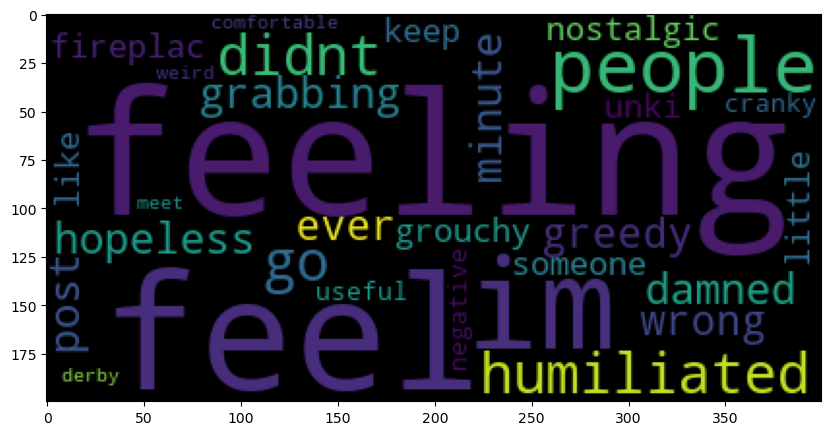

In [ ]:
from wordcloud import WordCloud
cloud=WordCloud(stopwords=stopwords.words('english'),max_words=30).generate(str(em['x']))
plt.figure(figsize=(10,10))
plt.imshow(cloud)

In [ ]:
em.y.value_counts()

y
6    6056
1    5247
2    2434
5    2161
3    1463
4     638
Name: count, dtype: int64

In [ ]:
em_emo_df=em[em.y==1]

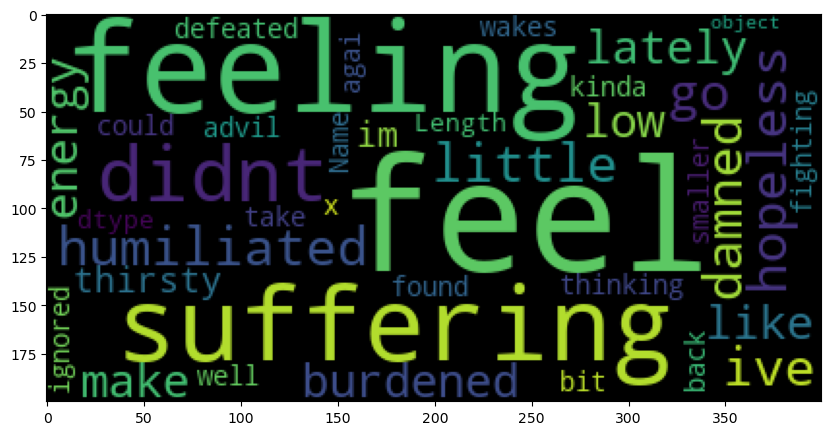

In [ ]:
from wordcloud import WordCloud
cloud=WordCloud(stopwords=stopwords.words('english'),max_words=40).generate(str(em_emo_df['x']))
plt.figure(figsize=(10,10))
plt.imshow(cloud)

In [ ]:
##-->em=em.replace({'sadness':1,'anger':2,'love':3,'surprise':4,'fear':5,'joy':6})

In [ ]:
em_emo_df1=em[em.y==2]

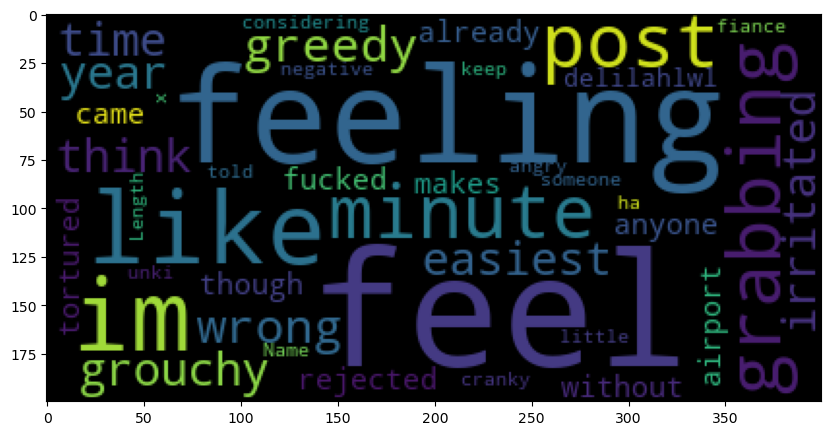

In [ ]:
cloud=WordCloud(stopwords=stopwords.words('english'),max_words=40).generate(str(em_emo_df1['x']))
plt.figure(figsize=(10,10))
plt.imshow(cloud)

In [ ]:
em_emo_df2=em[em.y==3]

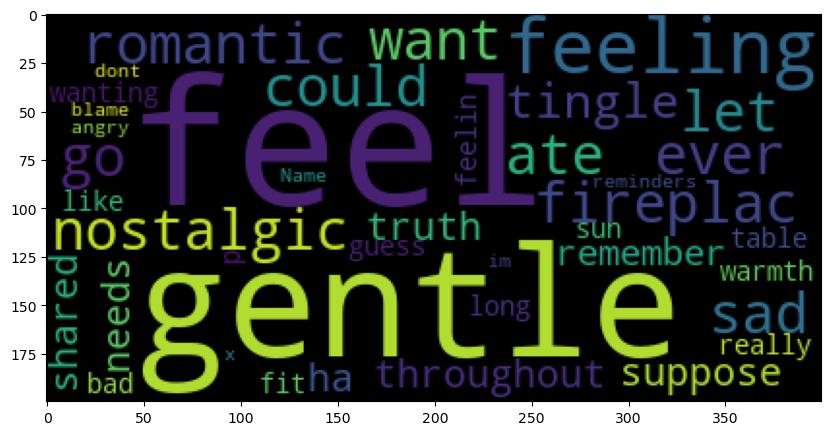

In [ ]:
cloud=WordCloud(stopwords=stopwords.words('english'),max_words=40).generate(str(em_emo_df2['x']))
plt.figure(figsize=(10,10))
plt.imshow(cloud)

In [ ]:
##-->em=em.replace({'sadness':1,'anger':2,'love':3,'surprise':4,'fear':5,'joy':6})

# TextBlob

In [ ]:
import nltk

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [ ]:
nltk.download('vader_lexicon') #dictionary or words

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\sudha\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
# vader is used for sentiment analysis --> +ve or -ve

In [ ]:
sent=SentimentIntensityAnalyzer()

In [ ]:
score=sent.polarity_scores('coffee was good and my brain cells finally got activated')
score

{'neg': 0.0, 'neu': 0.756, 'pos': 0.244, 'compound': 0.4404}

In [ ]:
#Proportion of text that is negative
#Proportion that is neutral
#Proportion that is positive
#Overall sentiment score, ranges from -1 (very negative) to +1 (very positive)

In [ ]:
sent.polarity_scores('AI a opportunity or threat?')

{'neg': 0.415, 'neu': 0.244, 'pos': 0.341, 'compound': -0.1531}

In [ ]:
type(score)

dict

In [ ]:
score.keys()

dict_keys(['neg', 'neu', 'pos', 'compound'])

In [ ]:
score['compound']

0.4404

In [ ]:
#trip=pd.read_csv(r"C:\Users\Vijay\OneDrive\Desktop\Files\Trip_advisor_review.csv")
tr=trip=pd.read_csv(r"C:\Users\sudha\OneDrive\Desktop\files\Files\Trip_advisor_review.csv")
tr

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5
...,...,...
20486,"best kept secret 3rd time staying charm, not 5...",5
20487,great location price view hotel great quick pl...,4
20488,"ok just looks nice modern outside, desk staff ...",2
20489,hotel theft ruined vacation hotel opened sept ...,1


In [ ]:
# consider you dont have rating column with you

In [ ]:
l1=list(tr['Review'])

In [ ]:
l1

['nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway, maybe just noisy neighbors, aveda bath products nice, did not goldfish stay nice touch taken advantage staying longer, location great walking distance shopping, overall nice experience having pay 40 parking night,  ',
 'ok nothing special charge diamond member hilton decided chain shot 20th anniversary seattle, start booked suite paid extra website description not, suite bedroom bathroom standard hotel room, took printed reservation desk showed said things like tv couch ect desk clerk told oh mixed suites description kimpton website sorry free breakfast, got kidding, embassy suits sitting room bathroom bedroom un

In [ ]:
l2=[]
for i in l1:
    score=sent.polarity_scores(i)
    l2.append(score['compound'])

In [ ]:
len(l2)

20491

In [ ]:
tr['score']=l2

In [ ]:
tr1=tr

In [ ]:
tr1 = tr1.drop('Rating', axis=1)
tr1

,Review,score
0,nice hotel expensive parking got good deal sta...,0.9747
1,ok nothing special charge diamond member hilto...,0.9787
2,nice rooms not 4* experience hotel monaco seat...,0.9889
3,"unique, great stay, wonderful time hotel monac...",0.9912
4,"great stay great stay, went seahawk game aweso...",0.9797
...,...,...
20486,"best kept secret 3rd time staying charm, not 5...",0.9834
20487,great location price view hotel great quick pl...,0.9753
20488,"ok just looks nice modern outside, desk staff ...",0.2629
20489,hotel theft ruined vacation hotel opened sept ...,0.9867


In [ ]:
20491-18862

1629

In [ ]:
tr1['score'].describe()

count    20491.000000
mean         0.803430
std          0.455671
min         -0.997400
25%          0.918400
50%          0.973800
75%          0.988800
max          0.999900
Name: score, dtype: float64

In [ ]:
tr1[tr1['score']>0].shape

#20000 → number of rows where score > 0
#5 → number of columns in the DataFrame

(18862, 2)

In [ ]:
20491-18862

1629

In [ ]:
# Your dataset has mostly strongly positive sentiment, with some negative outliers.
# If you're analyzing customer reviews, for instance, this would suggest customers are generally very happy.
# Would you like a visualization (e.g., histogram or boxplot) of this distribution?

# TextBlob

In [ ]:
from textblob import TextBlob
score=TextBlob('food was not tasty and was bad')

In [ ]:
score.sentiment

Sentiment(polarity=-0.6999999999999998, subjectivity=0.6666666666666666)

In [ ]:
score=TextBlob('bad good')
score.sentiment

Sentiment(polarity=5.551115123125783e-17, subjectivity=0.6333333333333333)

In [ ]:
score=TextBlob('')
score.sentiment
l1=list(tr['Review'])

In [ ]:
l2=[]
for i in l1:
    score=TextBlob(i)
    l2.append(score.sentiment[0])

# 0 polarity

In [ ]:
l2

[0.20874404761904758,
 0.21492277992277992,
 0.29441964285714284,
 0.5048245614035087,
 0.38461538461538464,
 0.2430555555555556,
 0.36666065416065424,
 0.5629629629629629,
 0.3129464285714286,
 0.2863553113553114,
 0.24166666666666664,
 0.23451178451178448,
 0.2384178321678322,
 -0.09166666666666666,
 0.3050925925925926,
 0.006510416666666666,
 0.16041092745638202,
 0.3420987654320988,
 0.5,
 0.10115942028985507,
 0.17738095238095236,
 0.596875,
 0.38083333333333336,
 0.28802083333333334,
 0.259375,
 0.2518518518518519,
 0.46851851851851856,
 0.06562499999999999,
 0.3052838827838828,
 0.45698593073593075,
 0.3439102564102564,
 0.1893772893772894,
 0.11683673469387755,
 0.1263888888888889,
 0.2541666666666667,
 0.32475490196078427,
 0.30333333333333334,
 0.3077272727272727,
 0.12142857142857144,
 0.49375,
 -0.027838827838827827,
 0.33915343915343915,
 -0.22999999999999998,
 0.1741758241758242,
 -0.04305555555555555,
 0.1283900091136933,
 0.11168831168831167,
 0.19564102564102565,
 0.52

In [ ]:
tr['score'].describe()

count    20491.000000
mean         0.803430
std          0.455671
min         -0.997400
25%          0.918400
50%          0.973800
75%          0.988800
max          0.999900
Name: score, dtype: float64

In [ ]:
score.sentiment


Sentiment(polarity=0.11061507936507936, subjectivity=0.6261904761904762)

In [ ]:
len(tr[tr['score']>0])
# Count of positive reviews

18862

In [ ]:
len(tr[tr['score']<0])
# Count of negative reviews

1617

In [ ]:
tr.shape

(20491, 3)

In [ ]:
18862/20491*100
#This is calculating the percentage of something, most likely positive reviews:

92.05016836659998

In [ ]:
import spacy

In [ ]:
lang=spacy.load('en_core_web_sm')

In [ ]:
import spacy

spacy.cli.download("en_core_web_sm")

#Loads the English small model (en_core_web_sm),
#which includes tokenization, part-of-speech tagging, named entity recognition, etc.

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
doc=lang('stock market has been moving upwaards from last sessions')

In [ ]:
type(doc)

spacy.tokens.doc.Doc

In [ ]:
for i in doc:
    print(i.text)

stock
market
has
been
moving
upwaards
from
last
sessions


In [ ]:
# pos part of the speach
#This prints each token along with its part of speech, like NOUN, VERB, ADJ, etc.

In [ ]:
for i in doc:
    print(i.text,i.pos_)

stock NOUN
market NOUN
has AUX
been AUX
moving VERB
upwaards NOUN
from ADP
last ADJ
sessions NOUN


In [ ]:
doc3 = lang("my website is www.abc.com and my email id is xyz@gmail.com this is just an example")

for token in doc3:
    print(token)

my
website
is
www.abc.com
and
my
email
i
d
is
xyz@gmail.com
this
is
just
an
example


In [ ]:
doc2=lang('stock market has been moving upword from last few session . i hope it continues the upword journey')

In [ ]:
for j in doc2.sents:
    print(j)

stock market has been moving upword from last few session .
i hope it continues the upword journey


In [ ]:
doc6=lang('Vijay live in Pune which is part of Maharashtra and which is part of India')

In [ ]:
for token in doc6.ents:
    print(token)

#This prints named entities in the sentence.

Pune
Maharashtra
India


In [ ]:
for token in doc6.ents:
    print(token)
    print(token.label_)
    print(str(spacy.explain(token.label_)))
    print('----------------------')

Pune
LOC
Non-GPE locations, mountain ranges, bodies of water
----------------------
Maharashtra
NORP
Nationalities or religious or political groups
----------------------
India
GPE
Countries, cities, states
----------------------


In [ ]:
doc6=lang('Kangaroo Win the World Cup')
for token in doc6.ents:
    print(token)



Kangaroo Win
the World Cup


In [ ]:
for token in doc6.ents:
    print(token)
    print(token.label_)
    print(str(spacy.explain(token.label_)))
    print('----------------------')

Kangaroo Win
PERSON
People, including fictional
----------------------
the World Cup
EVENT
Named hurricanes, battles, wars, sports events, etc.
----------------------


In [ ]:
import nltk
from nltk.stem.snowball import SnowballStemmer

In [ ]:
stemmer=SnowballStemmer(language='english')

In [ ]:
word_list={'swim','swimmer','matches','mens','langhing','loving','humens','indians','finishing','watchs','fans','writting'}

In [ ]:
for word in word_list:
    print(word,'its stemming is-->','\t',stemmer.stem(word))

loving its stemming is--> 	 love
swim its stemming is--> 	 swim
indians its stemming is--> 	 indian
humens its stemming is--> 	 humen
finishing its stemming is--> 	 finish
matches its stemming is--> 	 match
writting its stemming is--> 	 writ
watchs its stemming is--> 	 watch
swimmer its stemming is--> 	 swimmer
mens its stemming is--> 	 men
langhing its stemming is--> 	 langh
fans its stemming is--> 	 fan
